In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from sktime.forecasting.naive import NaiveForecaster
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from scipy.special import inv_boxcox
from scipy.stats import boxcox
import pmdarima as pm




from sktime.performance_metrics.forecasting import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [3]:
df = pd.read_csv("Temperature.csv")

In [4]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [5]:
df = df.sort_values(by="Datetime")
df = df.reset_index(drop=True)

In [6]:
df["Hourly_Temp"] = pd.to_numeric(df["Hourly_Temp"])

In [7]:
display(df.head())

,Datetime,Hourly_Temp
0,2022-01-04 00:00:00,20.867
1,2022-01-04 01:00:00,21.000
2,2022-01-04 02:00:00,20.867
3,2022-01-04 03:00:00,20.650
4,2022-01-04 04:00:00,20.400


In [8]:
train = df["Hourly_Temp"][:-int(0.2*len(df))]
test = df["Hourly_Temp"][-int(0.2*len(df)):]
train_df = df[:-int(0.2*len(df))]
test_df = df[-int(0.2*len(df)):]
time_stamps = int(0.2*len(df))+1

In [9]:
baseline_model = NaiveForecaster(strategy="mean")
baseline_model.fit(train)
y_pred = baseline_model.predict(fh=[i for i in range(1,time_stamps)])

In [10]:
prediction = pd.DataFrame({"Hourly_Temp":y_pred})
prediction["Datetime"] = test_df["Datetime"]

In [11]:
display(prediction)

,Hourly_Temp,Datetime
5645,21.336612,2022-08-27 05:00:00
5646,21.336612,2022-08-27 06:00:00
5647,21.336612,2022-08-27 07:00:00
5648,21.336612,2022-08-27 08:00:00
5649,21.336612,2022-08-27 09:00:00
...,...,...
7051,21.336612,2022-10-24 19:00:00
7052,21.336612,2022-10-24 20:00:00
7053,21.336612,2022-10-24 21:00:00
7054,21.336612,2022-10-24 22:00:00


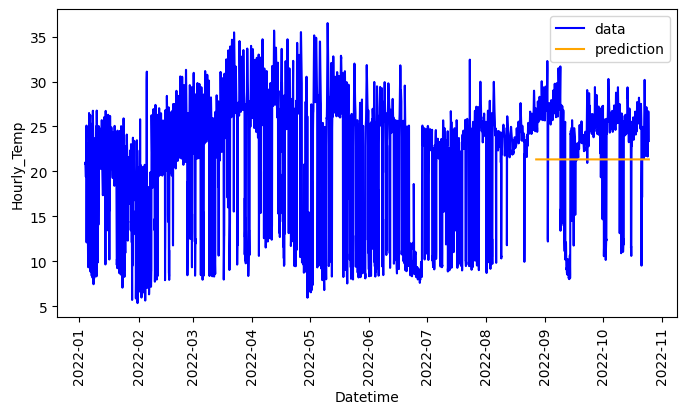

In [12]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Datetime",y="Hourly_Temp",color="blue",label="data")
sns.lineplot(data=prediction,x="Datetime",y="Hourly_Temp",color="orange",label="prediction")
plt.xticks(rotation=90)
plt.show()

In [13]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 4.782082357711991
RMSE: 5.4381171606031256
MAPE: 0.2410791335600088


# Using a more sophisticated model (ARIMA) and computing the performence metrics

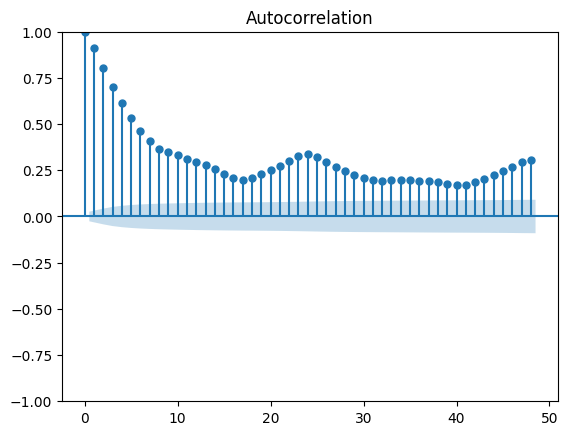

In [14]:
plot_acf(train,lags=48)
plt.show()

In [15]:
model_arima = ARIMA(train,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [16]:
prediction = pd.DataFrame({"Hourly_Temp":y_pred})
prediction["Datetime"] = test_df["Datetime"]

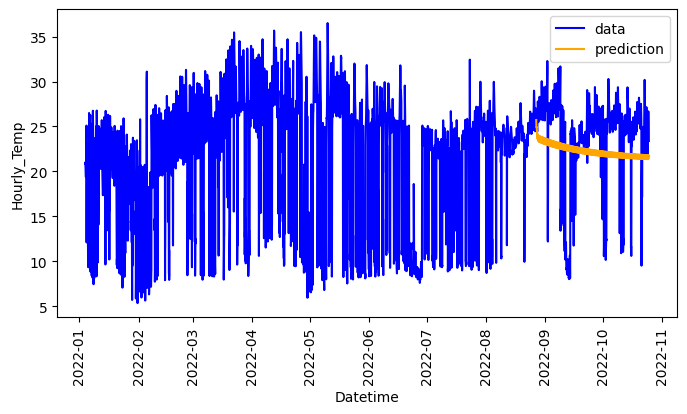

In [17]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Datetime",y="Hourly_Temp",color="blue",label="data")
sns.lineplot(data=prediction,x="Datetime",y="Hourly_Temp",color="orange",label="prediction")
plt.xticks(rotation=90)
plt.show()

In [18]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 4.092825551316168
RMSE: 5.037051683154966
MAPE: 0.22064373041960514


# Testing a different refinement method each time and looking at the performence

* The Box Cox

In [19]:
train_BoxCox, lam = boxcox(train)
model_arima = ARIMA(train_BoxCox,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))
y_pred = inv_boxcox(y_pred,lam)

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
prediction = pd.DataFrame({"Hourly_Temp":y_pred})
prediction.index = range(5645,5645+len(prediction))
prediction["Datetime"] = test_df["Datetime"]

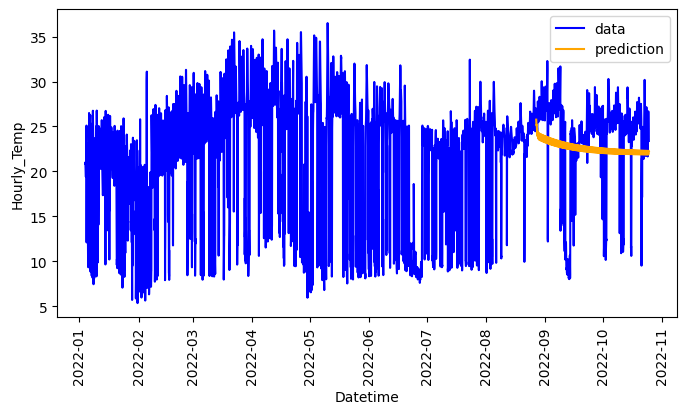

In [21]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Datetime",y="Hourly_Temp",color="blue",label="data")
sns.lineplot(data=prediction,x="Datetime",y="Hourly_Temp",color="orange",label="prediction")
plt.xticks(rotation=90)
plt.show()

In [22]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 3.868304581066191
RMSE: 4.921578668057671
MAPE: 0.21338093456979537


* IQR impuration with the median

In [23]:
median = np.median(train)
train_IQR = train.copy()
for i in range(len(train_IQR)):
    if train_IQR[i]>1.5*median:
        train_IQR[i] = median
        

In [24]:
model_arima = ARIMA(train_IQR,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [25]:
prediction = pd.DataFrame({"Hourly_Temp":y_pred})
prediction["Datetime"] = test_df["Datetime"]

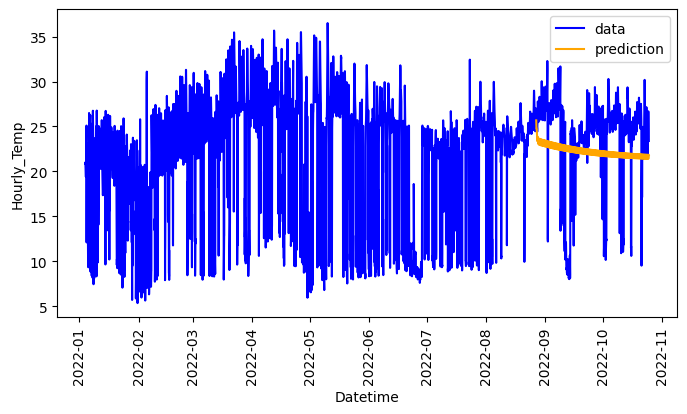

In [26]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Datetime",y="Hourly_Temp",color="blue",label="data")
sns.lineplot(data=prediction,x="Datetime",y="Hourly_Temp",color="orange",label="prediction")
plt.xticks(rotation=90)
plt.show()

In [27]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 4.125487410775404
RMSE: 5.0526052922818705
MAPE: 0.2215102099126953


* Fourier Trend

In [28]:
df_fourier = df.copy()

In [29]:
t = np.arange(len(df_fourier))
for order in range(1,10):
    df_fourier[f"fourier_sin_order_{order}"] = np.sin(2* np.pi * order * t*10)
    df_fourier[f"fourier_cos_order_{order}"] = np.cos(2* np.pi * order * t*10)
    
fourier_features = [i for i in list(df_fourier) if i.startswith("fourier")]
train_df_fourier = df_fourier[:-int(0.2*len(df))]
test_df_fourier = df_fourier[-int(0.2*len(df)):]

In [30]:
model = pm.auto_arima(
    train_df_fourier["Hourly_Temp"],
    X = train_df_fourier[fourier_features],
    seasonal = False,
    stepwise = True,
    suppress_warnings = True,
    max_order = None,
    information_criterion = "aicc",
    error_action = "ignore"
)
y_pred = model.predict(n_periods = len(test_df_fourier), X=test_df_fourier[fourier_features])

In [31]:
prediction = pd.DataFrame({"Hourly_Temp":y_pred})
prediction["Datetime"] = test_df["Datetime"]

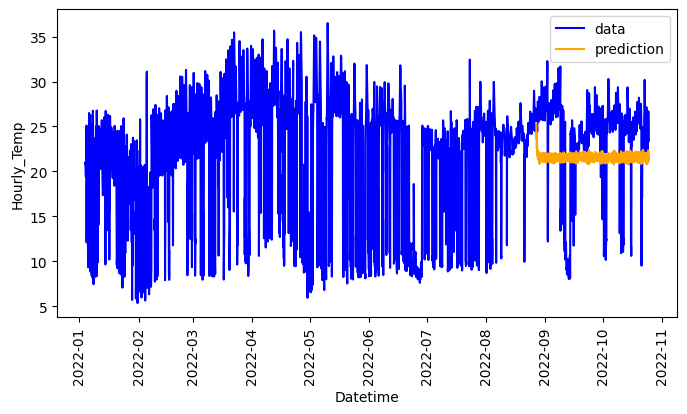

In [32]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df_fourier,x="Datetime",y="Hourly_Temp",color="blue",label="data")
sns.lineplot(data=prediction,x="Datetime",y="Hourly_Temp",color="orange",label="prediction")
plt.xticks(rotation=90)
plt.show()

In [33]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 4.603016746267272
RMSE: 5.331655159956635
MAPE: 0.23513463299198306


* Seasonal Differencing

In [34]:
df_diff = df.diff(24)
train_diff = df["Hourly_Temp"][:-int(0.2*len(df))]
test_diff = df["Hourly_Temp"][-int(0.2*len(df)):]

train_diff.dropna(inplace=True)
base = df.iloc[int(-len(df)*0.2)-24].loc["Hourly_Temp"]

In [35]:
train_diff = df_diff["Hourly_Temp"]

In [36]:
model_arima = ARIMA(train_diff,order=(20,0,20))
model_arima = model_arima.fit()
y_pred_diff = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [37]:
y_pred_diff = list(y_pred_diff)

In [38]:
y_pred = [y_pred_diff[0]+base]
for i in range(1,len(test)):
    y_pred.append(y_pred_diff[i]+y_pred[-1])

In [39]:
prediction = pd.DataFrame({"Hourly_Temp":y_pred})
prediction.index = range(5645,5645+len(test))
prediction["Datetime"] = test_df["Datetime"]


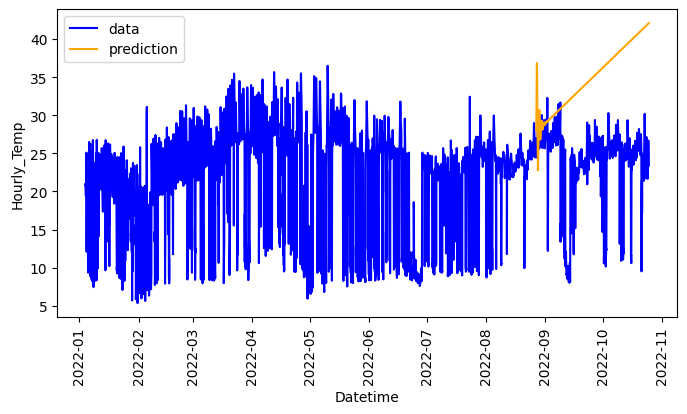

In [40]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Datetime",y="Hourly_Temp",color="blue",label="data")
sns.lineplot(data=prediction,x="Datetime",y="Hourly_Temp",color="orange",label="prediction")
plt.xticks(rotation=90)
plt.show()

In [41]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 11.05806826563208
RMSE: 12.659383215072442
MAPE: 0.5674127330639064


# Testing the LSTM neural network

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

I0000 00:00:1786629171.558123   19641 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786629171.563649   19641 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786629172.013922   19641 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786629174.554146   19641 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [43]:
# Prepare data
def create_sequences(data, seq_len=20):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i])
    return np.array(X), np.array(y)


seq_len = 20
X_train, y_train = create_sequences(train.values, seq_len)
X_test, y_test = create_sequences(test.values, seq_len)

# Reshape for LSTM [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Minimal LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_len, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# Fit and predict (like ARIMA)
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
y_pred = model.predict(X_test).flatten()

E0000 00:00:1786629175.571970   19641 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [44]:
prediction = pd.DataFrame({"Hourly_Temp":y_pred})
prediction.index = range(5645,5645+len(prediction))
prediction["Datetime"] = test_df["Datetime"]

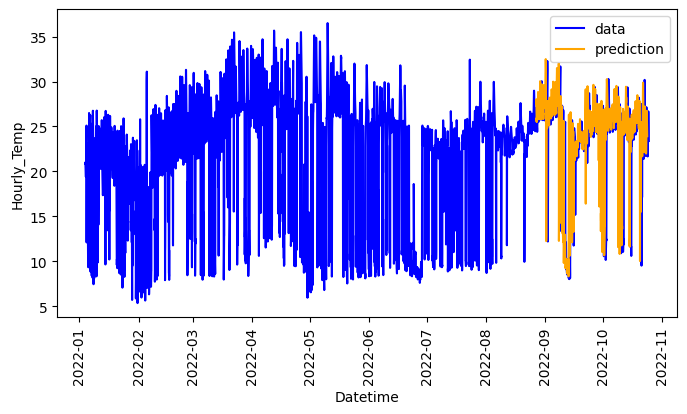

In [45]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Datetime",y="Hourly_Temp",color="blue",label="data")
sns.lineplot(data=prediction,x="Datetime",y="Hourly_Temp",color="orange",label="prediction")
plt.xticks(rotation=90)
plt.show()

In [46]:
test_LSTM = test[:-20]
len(test_LSTM)

1391

In [47]:
mae = mean_absolute_error(test_LSTM, y_pred)
rmse = mean_squared_error(test_LSTM, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test_LSTM, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 2.672045368120535
RMSE: 4.579139984409044
MAPE: 0.1432909319644903
